In [7]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from BFmodule import DR

Elsa=DR()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Elsa v2.4.2


In [8]:
from HPIB.HP4155 import HP4155
from HPIB.HPT import Plot, PlotVgs, PlotVp, CalcIsSat, SecDer, Plot2P
from HPIB.DevParams import UMC
from HPIB.INOSerial import Arduino

from YFunc import YFuncExtraction

from IPython.display import clear_output, display
from os import makedirs, rename
from time import sleep
from datetime import datetime, timedelta

In [4]:
if False:
    HP=HP4155("GPIB0::17", debug=False)
    HP.reset()
    HP.IntTime="LONG"

    INO=Arduino("COM3")
    print(INO.ask('*'.encode()))

HEWLETT-PACKARD,4155A,0,01.04:01.04:01.00
InoMatrix



In [3]:
failsafe_time=[60, 120, 120, 60] ## Maximum wait time between measurements (API crash failsafe)
failsafe_temp=[0, 120, 180, 300] ## is fitted from these temps and times
failsafe=np.polyfit(failsafe_time, failsafe_temp, 2)
print(failsafe)

[-2.38095238e-03  4.28571429e-01  1.32857143e+02]


C:\Users\Zucchi\AppData\Local\Temp\ipykernel_9984\2081629215.py:3: RankWarning: Polyfit may be poorly conditioned
  failsafe=np.polyfit(failsafe_time, failsafe_temp, 2)


In [38]:
path="C:/Users/Zucchi/Documents/Medidas/241210 TP7 TP9 TP5 TN3/Cold/TP5/"

from os import listdir

print(listdir(path))

path=path+'IdVgsSat - 004.073 - 241211 1631.csv'

df=pd.read_csv(path, header=[0, 1])

['desktop.ini', 'IdVds - 003.574 - 241212 1149.csv', 'IdVds - 003.574 - 241212 1149.png', 'IdVds - 003.578 - 241212 1046.csv', 'IdVds - 003.578 - 241212 1046.png', 'IdVds - 003.832 - 241211 1840.csv', 'IdVds - 003.832 - 241211 1840.png', 'IdVds - 003.933 - 241211 1737.csv', 'IdVds - 003.933 - 241211 1737.png', 'IdVds - 004.052 - 241211 1634.csv', 'IdVds - 004.052 - 241211 1634.png', 'IdVgs - 003.574 - 241212 1145.csv', 'IdVgs - 003.574 - 241212 1145.png', 'IdVgs - 003.578 - 241212 1041.csv', 'IdVgs - 003.578 - 241212 1041.png', 'IdVgs - 003.578 - 241212 1041IdFit.png', 'IdVgs - 003.847 - 241211 1836.csv', 'IdVgs - 003.847 - 241211 1836.png', 'IdVgs - 003.847 - 241211 1836IdFit.png', 'IdVgs - 003.950 - 241211 1733.csv', 'IdVgs - 003.950 - 241211 1733.png', 'IdVgs - 003.950 - 241211 1733IdFit.png', 'IdVgs - 004.076 - 241211 1630.csv', 'IdVgs - 004.076 - 241211 1630.png', 'IdVgs - 004.076 - 241211 1630IdFit.png', 'IdVgsSat - 003.579 - 241212 1146.csv', 'IdVgsSat - 003.579 - 241212 1146.pn

In [39]:
Id=df['Id'][df['Id'].columns[0]].to_numpy()
Vg=df['Vg'][df['Vg'].columns[0]].to_numpy()
Vd=float(df.columns[2][1])

In [40]:
if np.average(Id) < 0:
        Vd=-1*Vd
        Vg=-1*Vg
        Id=-1*Id

In [23]:
Vg

array([-0.  ,  0.02,  0.04,  0.06,  0.08,  0.1 ,  0.12,  0.14,  0.16,
        0.18,  0.2 ,  0.22,  0.24,  0.26,  0.28,  0.3 ,  0.32,  0.34,
        0.36,  0.38,  0.4 ,  0.42,  0.44,  0.46,  0.48,  0.5 ,  0.52,
        0.54,  0.56,  0.58,  0.6 ,  0.62,  0.64,  0.66,  0.68,  0.7 ,
        0.72,  0.74,  0.76,  0.78,  0.8 ,  0.82,  0.84,  0.86,  0.88,
        0.9 ,  0.92,  0.94,  0.96,  0.98,  1.  ,  1.02,  1.04,  1.06,
        1.08,  1.1 ,  1.12,  1.14,  1.16,  1.18,  1.2 ,  1.22,  1.24,
        1.26,  1.28,  1.3 ,  1.32,  1.34,  1.36,  1.38,  1.4 ,  1.42,
        1.44,  1.46,  1.48,  1.5 ])

(127.90867513362076, 3.1652679374026067e-09)

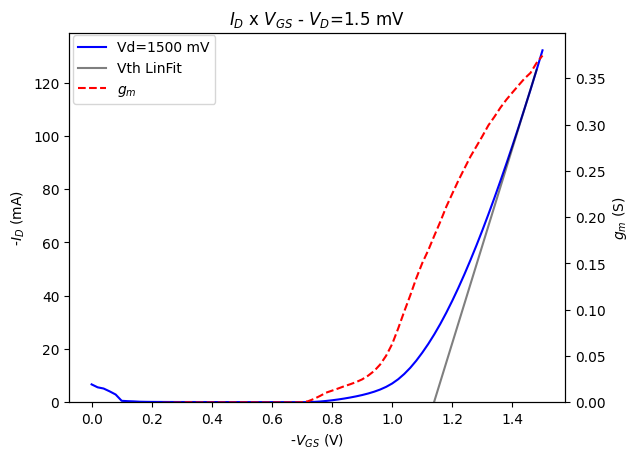

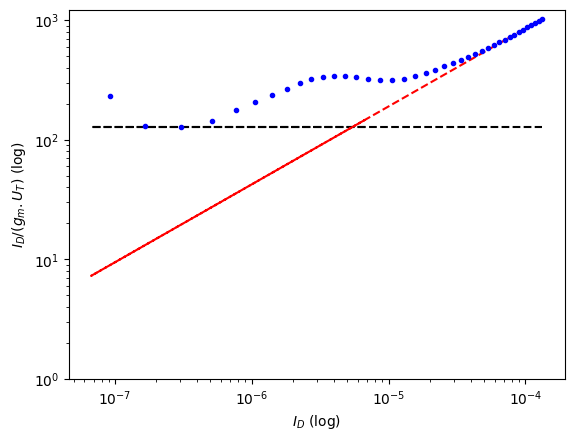

In [41]:
CalcIsSat(path, 4)